# **Data Loading and Cleaning**

In [ ]:
import numpy as np
import pandas as pd

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


In [ ]:
import os, sys, json, warnings
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

warnings.filterwarnings("ignore")
pd.set_option("display.max_colwidth", 80)

DATA_DIR = "/content"
OUTPUT_DIR = "clean_data"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"Data dir   : {os.path.abspath(DATA_DIR)}")
print(f"Output dir : {os.path.abspath(OUTPUT_DIR)}")

Data dir   : /content
Output dir : /content/clean_data


## Load & Raw Data Exploration

In [ ]:
splits = ["train", "validation", "test"]
raw = {}
for s in splits:
    path = os.path.join(DATA_DIR, f"{s}.csv")
    raw[s] = pd.read_csv(path, on_bad_lines='skip', engine='python')
    print(f"[{s:>10}]  rows={len(raw[s]):>7,}  cols={list(raw[s].columns)}")

[     train]  rows=174,689  cols=['id', 'article', 'highlights']
[validation]  rows= 13,368  cols=['id', 'article', 'highlights']
[      test]  rows= 11,490  cols=['id', 'article', 'highlights']


In [ ]:
raw["train"].head(3)

,id,article,highlights
0,0001d1afc246a7964130f43ae940af6bc6c57f01,"By . Associated Press . PUBLISHED: . 14:11 EST, 25 October 2013 . | . UPDATE...","Bishop John Folda, of North Dakota, is taking time off after being diagnosed..."
1,0002095e55fcbd3a2f366d9bf92a95433dc305ef,(CNN) -- Ralph Mata was an internal affairs lieutenant for the Miami-Dade Po...,Criminal complaint: Cop used his role to help cocaine traffickers .\nRalph M...
2,00027e965c8264c35cc1bc55556db388da82b07f,A drunk driver who killed a young woman in a head-on crash while checking hi...,"Craig Eccleston-Todd, 27, had drunk at least three pints before driving car ..."


In [ ]:
raw["train"].dtypes

,0
id,object
article,object
highlights,object


In [ ]:
null_summary = pd.DataFrame({
    s: raw[s].isnull().sum() for s in splits
}).T
print("── Null counts ──")
print(null_summary)

── Null counts ──
            id  article  highlights
train        0        0           0
validation   0        0           0
test         0        0           0


In [ ]:
for s in splits:
    dupes = raw[s].duplicated(subset=["id"]).sum()
    print(f"[{s}] duplicate IDs: {dupes}")

[train] duplicate IDs: 0
[validation] duplicate IDs: 0
[test] duplicate IDs: 0


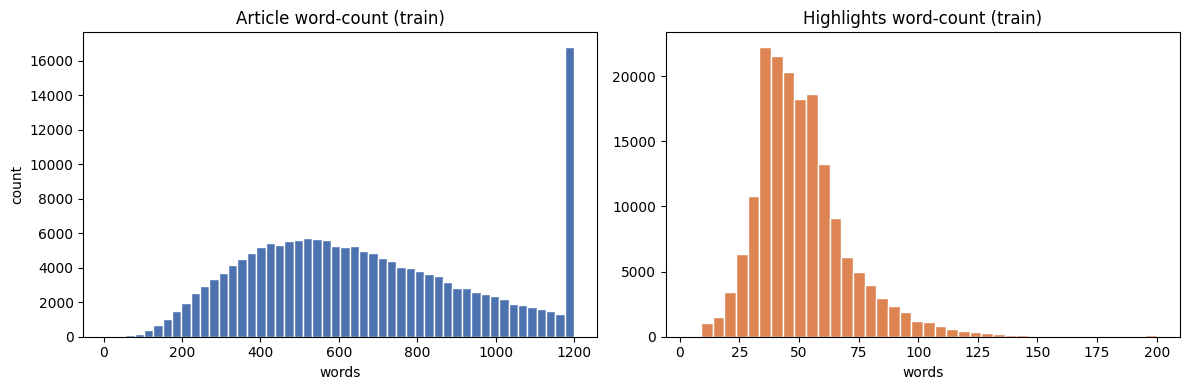

Article  — mean: 692  median: 631  max: 2226
Highlight— mean: 52  median: 48  max: 1296


In [ ]:
train_art_wc  = raw["train"]["article"].dropna().str.split().str.len()
train_high_wc = raw["train"]["highlights"].dropna().str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(train_art_wc.clip(upper=1200), bins=50, color="#4C72B0", edgecolor="white")
axes[0].set_title("Article word-count (train)")
axes[0].set_xlabel("words"); axes[0].set_ylabel("count")

axes[1].hist(train_high_wc.clip(upper=200), bins=40, color="#DD8452", edgecolor="white")
axes[1].set_title("Highlights word-count (train)")
axes[1].set_xlabel("words")

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "word_count_distribution.png"), dpi=120)
plt.show()
print(f"Article  — mean: {train_art_wc.mean():.0f}  median: {train_art_wc.median():.0f}  max: {train_art_wc.max()}")
print(f"Highlight— mean: {train_high_wc.mean():.0f}  median: {train_high_wc.median():.0f}  max: {train_high_wc.max()}")

## Data Cleaning
| Step | Action |
|------|--------|
| 1 | Drop rows where `article` **or** `highlights` is null |
| 2 | Strip leading/trailing whitespace |
| 3 | Drop empty strings after strip |
| 4 | Deduplicate by `id` |
| 5 | Filter by word-count thresholds |

In [ ]:
MIN_ARTICLE_WORDS    = 30
MIN_HIGHLIGHTS_WORDS = 5
MAX_ARTICLE_WORDS    = 2_000

def clean_df(df: pd.DataFrame, label: str = "") -> pd.DataFrame:
    tag = f"[{label}] " if label else ""
    orig = len(df)

    # 1. Drop nulls
    df = df.dropna(subset=["article", "highlights"])

    # 2. Strip whitespace
    df["article"]    = df["article"].str.strip()
    df["highlights"] = df["highlights"].str.strip()

    # 3. Drop empty strings
    df = df[(df["article"].str.len() > 0) & (df["highlights"].str.len() > 0)]

    # 4. Deduplicate
    df = df.drop_duplicates(subset=["id"])

    # 5. Word-count filter
    aw = df["article"].str.split().str.len()
    hw = df["highlights"].str.split().str.len()
    df = df[(aw >= MIN_ARTICLE_WORDS) & (aw <= MAX_ARTICLE_WORDS) & (hw >= MIN_HIGHLIGHTS_WORDS)]

    df = df.reset_index(drop=True)
    print(f"{tag}  {orig:>7,} → {len(df):>7,} rows  (removed {orig-len(df):,})")
    return df

clean = {}
print("Split          raw      clean    removed")
print("─" * 44)
for s in splits:
    clean[s] = clean_df(raw[s].copy(), label=s)


Split          raw      clean    removed
────────────────────────────────────────────
[train]   174,689 → 174,677 rows  (removed 12)
[validation]    13,368 →  13,368 rows  (removed 0)
[test]    11,490 →  11,490 rows  (removed 0)


## Verify Cleaned Data

In [ ]:
verify = pd.DataFrame({
    s: {
        "rows":           len(clean[s]),
        "nulls_article":  clean[s]["article"].isnull().sum(),
        "nulls_highlights":clean[s]["highlights"].isnull().sum(),
        "duplicates":     clean[s].duplicated(subset=["id"]).sum(),
        "avg_art_words":  round(clean[s]["article"].str.split().str.len().mean(),1),
        "avg_high_words": round(clean[s]["highlights"].str.split().str.len().mean(),1),
    }
    for s in splits
}).T
verify

,rows,nulls_article,nulls_highlights,duplicates,avg_art_words,avg_high_words
train,174677.0,0.0,0.0,0.0,691.5,51.6
validation,13368.0,0.0,0.0,0.0,676.0,57.9
test,11490.0,0.0,0.0,0.0,683.5,55.0


## Visualization Of Cleaned Data

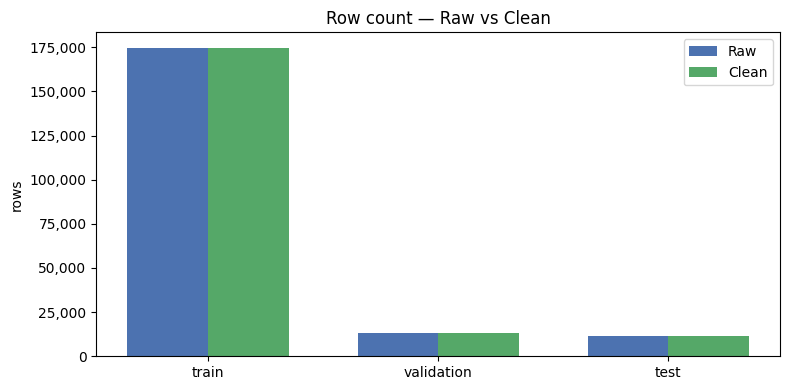

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))
x = range(len(splits))
w = 0.35
ax.bar([i - w/2 for i in x], [len(raw[s]) for s in splits],  width=w, label="Raw",   color="#4C72B0")
ax.bar([i + w/2 for i in x], [len(clean[s]) for s in splits], width=w, label="Clean", color="#55A868")
ax.set_xticks(list(x)); ax.set_xticklabels(splits)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f"{int(v):,}"))
ax.set_title("Row count — Raw vs Clean"); ax.set_ylabel("rows"); ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "raw_vs_clean.png"), dpi=120)
plt.show()


## Save Clean CSVs

In [ ]:
for s in splits:
    out = os.path.join(OUTPUT_DIR, f"clean_{s}.csv")
    clean[s].to_csv(out, index=False)
    print(f"Saved → {out}  ({len(clean[s]):,} rows)")

Saved → clean_data/clean_train.csv  (174,677 rows)
Saved → clean_data/clean_validation.csv  (13,368 rows)
Saved → clean_data/clean_test.csv  (11,490 rows)


In [ ]:
import pandas as pd

df = pd.read_csv("clean_data/clean_train.csv")
df.head()

,id,article,highlights
0,0001d1afc246a7964130f43ae940af6bc6c57f01,"By . Associated Press . PUBLISHED: . 14:11 EST, 25 October 2013 . | . UPDATE...","Bishop John Folda, of North Dakota, is taking time off after being diagnosed..."
1,0002095e55fcbd3a2f366d9bf92a95433dc305ef,(CNN) -- Ralph Mata was an internal affairs lieutenant for the Miami-Dade Po...,Criminal complaint: Cop used his role to help cocaine traffickers .\nRalph M...
2,00027e965c8264c35cc1bc55556db388da82b07f,A drunk driver who killed a young woman in a head-on crash while checking hi...,"Craig Eccleston-Todd, 27, had drunk at least three pints before driving car ..."
3,0002c17436637c4fe1837c935c04de47adb18e9a,(CNN) -- With a breezy sweep of his pen President Vladimir Putin wrote a new...,Nina dos Santos says Europe must be ready to accept sanctions will hurt both...
4,0003ad6ef0c37534f80b55b4235108024b407f0b,Fleetwood are the only team still to have a 100% record in Sky Bet League On...,"Fleetwood top of League One after 2-0 win at Scunthorpe .\nPeterborough, Bri..."


# **Data Preprocessing**

In [ ]:
import re
import pandas as pd
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')
stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [ ]:
def fast_sentence_split(text):
    if not isinstance(text, str):
        return []
    return [s.strip() for s in text.split('.') if len(s.strip()) > 5]

In [ ]:
def preprocess_text_fast(text):
    if not isinstance(text, str):
        return {"sentences": [], "tokens": [], "clean_text": ""}

    # clean first
    clean_text = text.lower()
    clean_text = re.sub(r'[^a-zA-Z\s]', '', clean_text)

    # fast sentence split (original text)
    sentences = fast_sentence_split(text)
    sentences = [s.strip() for s in sentences if len(s.split()) > 5]

    # tokenize cleaned text
    words = word_tokenize(clean_text)

    # remove stopwords
    words = [w for w in words if w not in stop_words and w.strip() != ""]

    return {
        "sentences": sentences,
        "tokens": words,
        "clean_text": " ".join(words)
    }

In [ ]:
sample = df["article"].iloc[0]

result = preprocess_text_fast(sample)

print(result["sentences"][:3])
print(result["clean_text"][:200])

['The bishop of the Fargo Catholic Diocese in North Dakota has exposed potentially hundreds of church members in Fargo, Grand Forks and Jamestown to the hepatitis A virus in late September and early October', 'The state Health Department has issued an advisory of exposure for anyone who attended five churches and took communion', 'Bishop John Folda (pictured) of the Fargo Catholic Diocese in North Dakota has exposed potentially hundreds of church members in Fargo, Grand Forks and Jamestown to the hepatitis A']
associated press published est october updated est october bishop fargo catholic diocese north dakota exposed potentially hundreds church members fargo grand forks jamestown hepatitis virus late septe


In [ ]:
from tqdm import tqdm
tqdm.pandas()

df = df.sample(5000, random_state=42)

df["processed"] = df["article"].progress_apply(preprocess_text_fast)

100%|██████████| 5000/5000 [00:11<00:00, 452.34it/s]


In [ ]:

df["sentences"] = df["processed"].apply(lambda x: x["sentences"])
df["clean_text"] = df["processed"].apply(lambda x: x["clean_text"])

In [ ]:
df.to_csv("clean_data/preprocessed_train_fast.csv", index=False)

In [ ]:
print(df.shape)
print(df.columns)
print(df.head(1))

(5000, 6)
Index(['id', 'article', 'highlights', 'processed', 'sentences', 'clean_text'], dtype='object')
                                              id  \
145902  48aa39c5079dc815413437d190f5ba4f554d9af3   

                                                                                article  \
145902  By . John Hall . A Scottish farmer has spent £5,000 on CCTV cameras and guar...   

                                                                             highlights  \
145902  Raymond Irvine paid £55,000 for 10 Valais Blacknose ewes and one ram .\nAdor...   

                                                                              processed  \
145902  {'sentences': ['A Scottish farmer has spent £5,000 on CCTV cameras and guard...   

                                                                              sentences  \
145902  [A Scottish farmer has spent £5,000 on CCTV cameras and guard dogs to protec...   

                                                          

In [ ]:
print(df["processed"].iloc[0])

{'sentences': ["A Scottish farmer has spent £5,000 on CCTV cameras and guard dogs to protect his new flock of the 'world's cutest sheep'", 'Raymond Irvine paid £55,000 for 10 ewes and one ram of the Valais Blacknose breed and now intends to breed them at his farm near Tomintoul in Moray', "The sheep, which are only found in Switzerland, are well-known for their shaggy coats and spiral horns, but it is their distinctive, incredibly dark 'black hole' faces - which look as if they have been Photoshopped to have all features removed - that draw much of the attention", "Adorable: The sheep, which originate in Switzerland, are well-known for their shaggy coats and spiral horns, but it is their distinctive, incredibly dark 'black hole' faces that draw much of the attention", 'Investment: Raymond Irvine paid £55,000 for 10 ewes and one ram (pictured) of the Valais Blacknose breed', 'He now intends to breed them at his farm near Tomintoul in Moray, Scotland', "Faceless: Scottish farmer Raymond 

In [ ]:
print(df["processed"].isnull().sum())

0


In [ ]:
df.sample(3)[["sentences", "clean_text"]]

,sentences,clean_text
57980,[Washington (CNN) -- Members of a key Democratic-controlled Senate panel cas...,washington cnn members key democraticcontrolled senate panel cast first cong...
161499,"[(CNN) -- The Cumberland River in Nashville, Tennessee, is predicted to be a...",cnn cumberland river nashville tennessee predicted flood stage overnight fri...
164357,"[As temperatures soared in Brazil, there must have been only one man who was...",daily mail reporter temperatures soared brazil must one man cool needed card...


# **Feature Extraction**

# Feature Engineering — Text Summarization System

**Step 2 of the NLP Pipeline**

This notebook builds on the preprocessed data (`preprocessed_train_fast.csv`) and performs:

| # | Task | Method |
|---|------|--------|
| 1 | **TF-IDF Features** | `TfidfVectorizer` → sentence scores |
| 2 | **Word2Vec Embeddings** | Train on corpus → sentence vectors |
| 3 | **Sentence Importance Score** | Combine TF-IDF + embedding similarity |
| 4 | **Save Features** | Persist for use in downstream summarization steps |

## 0 — Imports & Configuration

In [ ]:
import warnings, os, ast
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

# Install gensim if not already installed
try:
    from gensim.models import Word2Vec
except ImportError:
    !pip install gensim
    from gensim.models import Word2Vec

# directories
DATA_DIR   = 'clean_data'
OUTPUT_DIR = 'features'
os.makedirs(OUTPUT_DIR, exist_ok=True)

print('✅  All imports OK')
print(f'   Data directory   : {os.path.abspath(DATA_DIR)}')
print(f'   Feature directory: {os.path.abspath(OUTPUT_DIR)}')


✅  All imports OK
   Data directory   : /content/clean_data
   Feature directory: /content/features


## 1 — Load Preprocessed Data

In [ ]:
df = pd.read_csv(os.path.join(DATA_DIR, 'preprocessed_train_fast.csv'))

# parse 'sentences' column (stored as string repr of list)
def safe_parse_list(val):
    if isinstance(val, list):  return val
    try:                        return ast.literal_eval(val)
    except Exception:           return []

df['sentences'] = df['sentences'].apply(safe_parse_list)

# drop rows with empty sentences or clean_text
df = df[df['sentences'].map(len) > 0].reset_index(drop=True)
df = df[df['clean_text'].notna() & (df['clean_text'].str.strip() != '')].reset_index(drop=True)

print(f'Rows loaded : {len(df):,}')
print(f'Columns     : {list(df.columns)}')
df[['article', 'clean_text', 'sentences']].head(2)

Rows loaded : 5,000
Columns     : ['id', 'article', 'highlights', 'processed', 'sentences', 'clean_text']


,article,clean_text,sentences
0,"By . John Hall . A Scottish farmer has spent £5,000 on CCTV cameras and guar...",john hall scottish farmer spent cctv cameras guard dogs protect new flock wo...,"[A Scottish farmer has spent £5,000 on CCTV cameras and guard dogs to protec..."
1,(CNN) -- Police on Friday arrested a second contractor employee in recent dr...,cnn police friday arrested second contractor employee recent dry ice explosi...,[(CNN) -- Police on Friday arrested a second contractor employee in recent d...


## 2 — Feature Extraction: TF-IDF

### 2.1  Corpus-level TF-IDF vocabulary
We fit a `TfidfVectorizer` on the full corpus of **cleaned texts**.  
This learns which words are **rare across articles** (high IDF) and therefore carry strong signal.

In [ ]:
tfidf_vectorizer = TfidfVectorizer(
    max_features=20_000,   # keep top 20k vocabulary terms
    ngram_range=(1, 2),    # unigrams + bigrams
    sublinear_tf=True,     # apply log(1 + tf) smoothing
    min_df=2               # ignore terms appearing in < 2 docs
)

# Fit on cleaned text corpus
tfidf_matrix = tfidf_vectorizer.fit_transform(df['clean_text'])

print(f'Vocabulary size : {len(tfidf_vectorizer.vocabulary_):,}')
print(f'TF-IDF matrix   : {tfidf_matrix.shape}  (docs × terms)')

Vocabulary size : 20,000
TF-IDF matrix   : (5000, 20000)  (docs × terms)


### 2.2  Sentence-level TF-IDF score

For each article we:
1. Split into individual sentences (already done in preprocessing).
2. Vectorize each sentence using the fitted vocabulary.
3. Compute the **mean TF-IDF weight** of the sentence as its importance score.

Higher score → sentence contains more distinctive / important keywords.

In [ ]:
def score_sentences_tfidf(sentences, vectorizer):
    """
    Returns a list of TF-IDF importance scores, one per sentence.
    Score = mean of non-zero TF-IDF weights in that sentence.
    """
    if not sentences:
        return []

    # preprocess sentences the same way (lowercase, no punct)
    import re
    clean = [re.sub(r'[^a-zA-Z\s]', '', s.lower()) for s in sentences]

    try:
        mat = vectorizer.transform(clean)          # shape: (n_sents, vocab)
    except Exception:
        return [0.0] * len(sentences)

    # mean of non-zero entries per row
    scores = []
    for i in range(mat.shape[0]):
        row = mat.getrow(i)
        nz  = row.data
        scores.append(float(nz.mean()) if len(nz) > 0 else 0.0)

    return scores

# Apply to every article
from tqdm import tqdm
tqdm.pandas(desc='TF-IDF sentence scoring')

df['tfidf_scores'] = df['sentences'].progress_apply(
    lambda sents: score_sentences_tfidf(sents, tfidf_vectorizer)
)

# Sanity check on one article
idx = 0
print('\n── Sample article sentence scores ──')
for s, sc in zip(df['sentences'].iloc[idx][:5], df['tfidf_scores'].iloc[idx][:5]):
    print(f'  [{sc:.4f}]  {s[:80]}')

TF-IDF sentence scoring: 100%|██████████| 5000/5000 [00:21<00:00, 228.61it/s]


── Sample article sentence scores ──
  [0.2777]  A Scottish farmer has spent £5,000 on CCTV cameras and guard dogs to protect his
  [0.2894]  Raymond Irvine paid £55,000 for 10 ewes and one ram of the Valais Blacknose bree
  [0.2194]  The sheep, which are only found in Switzerland, are well-known for their shaggy 
  [0.2345]  Adorable: The sheep, which originate in Switzerland, are well-known for their sh
  [0.3079]  Investment: Raymond Irvine paid £55,000 for 10 ewes and one ram (pictured) of th


### 2.3  Visualise TF-IDF score distribution

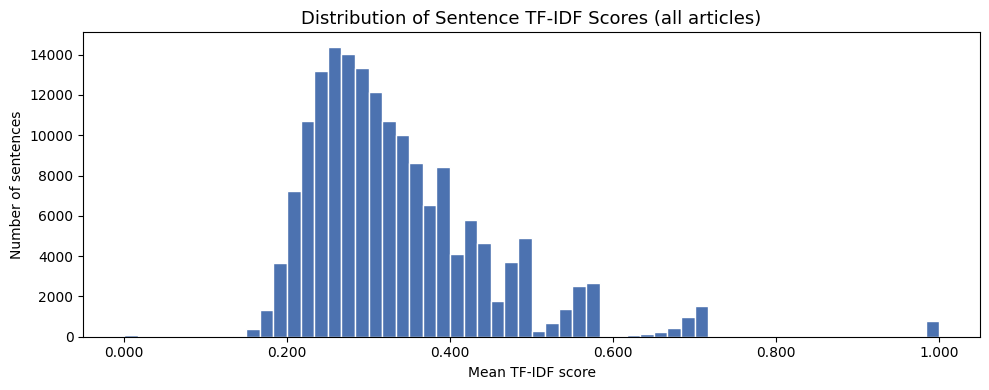

Score stats →  mean=0.3356  median=0.3092  max=1.0000


In [ ]:
all_scores = [sc for row in df['tfidf_scores'] for sc in row]

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(all_scores, bins=60, color='#4C72B0', edgecolor='white')
ax.set_title('Distribution of Sentence TF-IDF Scores (all articles)', fontsize=13)
ax.set_xlabel('Mean TF-IDF score')
ax.set_ylabel('Number of sentences')
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.3f'))
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'tfidf_score_distribution.png'), dpi=120)
plt.show()

print(f'Score stats →  mean={np.mean(all_scores):.4f}  '
      f'median={np.median(all_scores):.4f}  '
      f'max={np.max(all_scores):.4f}')

## 3 — Feature Extraction: Word2Vec Embeddings

### 3.1  Train Word2Vec on the corpus

We train a **Skip-gram Word2Vec** model on the tokenised texts.  
Each word gets a dense 100-dimensional vector that encodes **semantic meaning**.

In [ ]:
# Build list of token lists from clean_text column
from nltk.tokenize import word_tokenize

print('Tokenising corpus for Word2Vec training …')
token_corpus = [text.split() for text in df['clean_text'] if isinstance(text, str)]

print(f'  Documents : {len(token_corpus):,}')
print(f'  Avg tokens: {np.mean([len(t) for t in token_corpus]):.1f}')

# Train Word2Vec
w2v_model = Word2Vec(
    sentences=token_corpus,
    vector_size=100,   # embedding dimensions
    window=5,          # context window
    min_count=3,       # ignore words appearing < 3 times
    sg=1,              # 1 = Skip-gram, 0 = CBOW
    workers=4,
    epochs=5,
    seed=42
)

print(f'\n✅  Word2Vec trained')
print(f'   Vocabulary size : {len(w2v_model.wv):,} words')
print(f'   Embedding dims  : {w2v_model.vector_size}')

Tokenising corpus for Word2Vec training …
  Documents : 5,000
  Avg tokens: 379.2

✅  Word2Vec trained
   Vocabulary size : 37,724 words
   Embedding dims  : 100


### 3.2  Inspect the word vector space

A quick sanity-check — semantically similar words should appear close to each other.

In [ ]:
probe_words = ['government', 'police', 'economy', 'president', 'report']

print('── Most similar words (Word2Vec) ──\n')
for word in probe_words:
    if word in w2v_model.wv:
        similar = w2v_model.wv.most_similar(word, topn=5)
        similar_str = ', '.join([f"{w} ({s:.2f})" for w, s in similar])
        print(f'  {word:>12} → {similar_str}')
    else:
        print(f'  {word:>12} → (not in vocabulary)')

── Most similar words (Word2Vec) ──

    government → governments (0.75), russians (0.70), coalition (0.69), bureaucracy (0.67), bilateral (0.67)
        police → officers (0.79), detectives (0.73), nypd (0.67), detective (0.64), officer (0.64)
       economy → downturn (0.80), economies (0.78), economic (0.78), bloc (0.77), recession (0.77)
     president → barack (0.72), obama (0.68), presidents (0.65), biden (0.65), presidency (0.63)
        report → cnns (0.69), contributed (0.65), quan (0.60), messia (0.59), ahlers (0.59)


### 3.3  Sentence embeddings via mean-pooling

We represent each sentence as the **average Word2Vec vector** of its words.  
Words not in the vocabulary are skipped.

In [ ]:
def sentence_to_vector(sentence: str, model: Word2Vec) -> np.ndarray:
    """
    Mean-pool Word2Vec vectors for all known words in the sentence.
    Returns a zero vector if no words are in the vocabulary.
    """
    import re
    tokens = re.sub(r'[^a-zA-Z\s]', '', sentence.lower()).split()
    vecs   = [model.wv[w] for w in tokens if w in model.wv]
    if vecs:
        return np.mean(vecs, axis=0)          # shape: (vector_size,)
    return np.zeros(model.vector_size)


def get_sentence_embeddings(sentences, model):
    """Return a list of embedding vectors, one per sentence."""
    return [sentence_to_vector(s, model) for s in sentences]


# Apply — store as list of numpy arrays per document
tqdm.pandas(desc='Word2Vec sentence embeddings')

df['sentence_embeddings'] = df['sentences'].progress_apply(
    lambda sents: get_sentence_embeddings(sents, w2v_model)
)

# Show embedding for the first sentence of the first article
emb_sample = df['sentence_embeddings'].iloc[0][0]
print(f'Embedding shape : {emb_sample.shape}')
print(f'Sample values   : {emb_sample[:8].round(4)}')

Word2Vec sentence embeddings: 100%|██████████| 5000/5000 [00:11<00:00, 435.31it/s]

Embedding shape : (100,)
Sample values   : [ 0.1075 -0.105  -0.0859 -0.0072 -0.1669  0.1672 -0.084   0.1608]


### 3.4  Centroid similarity score

We compute the **document centroid** (mean of all sentence embeddings) and score each sentence by its **cosine similarity** to that centroid.  
Sentences that are *most representative* of the overall document get higher scores.

In [ ]:
def centroid_similarity_scores(sentence_embeddings):
    """
    Compute cosine similarity of each sentence embedding to the document centroid.
    """
    if not sentence_embeddings:
        return []

    matrix   = np.vstack(sentence_embeddings)           # (n_sents, dim)
    centroid = matrix.mean(axis=0, keepdims=True)       # (1, dim)

    sims = cosine_similarity(matrix, centroid).flatten()  # (n_sents,)
    return sims.tolist()


tqdm.pandas(desc='Centroid similarity scoring')

df['embedding_scores'] = df['sentence_embeddings'].progress_apply(
    centroid_similarity_scores
)

# Sanity check
idx = 1
print('\n── Centroid similarity scores (sample) ──')
for s, sc in zip(df['sentences'].iloc[idx][:5], df['embedding_scores'].iloc[idx][:5]):
    print(f'  [{sc:.4f}]  {s[:80]}')

Centroid similarity scoring: 100%|██████████| 5000/5000 [00:02<00:00, 1706.17it/s]


── Centroid similarity scores (sample) ──
  [0.9048]  (CNN) -- Police on Friday arrested a second contractor employee in recent dry ic
  [0.9297]  Miguel Angel Iniguez, 41, was a supervisor for 28-year-old baggage handler Dicar
  [0.9275]  The statement said Iniguez, of Inglewood, was booked on suspicion of possession 
  [0.7282]  He was being held on $500,000 bail
  [0.9477]  On Sunday, dry ice in a plastic bottle exploded in an employee restroom, causing


## 4 — Combined Sentence Importance Score

We merge the two signals into a single **importance score** per sentence:

$$\text{importance}(s_i) = \alpha \cdot \text{TF-IDF}(s_i) + (1-\alpha) \cdot \text{EmbeddingSim}(s_i)$$

- **TF-IDF score** → sentence contains key distinctive terms  
- **Embedding similarity** → sentence is representative of the document's topic

We normalise both signals to [0, 1] before combining.

In [ ]:
ALPHA = 0.3   # weight for TF-IDF; (1-ALPHA) goes to embedding similarity

def normalize(scores):
    """Min-max normalise a list of scores to [0, 1]."""
    arr = np.array(scores, dtype=float)
    rng = arr.max() - arr.min()
    if rng == 0:
        return np.zeros_like(arr).tolist()
    return ((arr - arr.min()) / rng).tolist()


def combined_importance(tfidf_scores, embedding_scores, alpha=ALPHA):
    """
    Weighted combination of normalised TF-IDF and embedding-centroid scores.
    """
    n = len(tfidf_scores)
    if n == 0:
        return []

    t_norm = normalize(tfidf_scores)
    e_norm = normalize(embedding_scores) if embedding_scores else [0.0] * n

    return [alpha * t + (1 - alpha) * e
            for t, e in zip(t_norm, e_norm)]


df['importance_scores'] = df.apply(
    lambda row: combined_importance(row['tfidf_scores'], row['embedding_scores']),
    axis=1
)

print('✅  Combined importance scores computed')
print(f'   Alpha (TF-IDF weight)          : {ALPHA}')
print(f'   (1-Alpha) (Embedding weight)   : {1 - ALPHA}')

✅  Combined importance scores computed
   Alpha (TF-IDF weight)          : 0.3
   (1-Alpha) (Embedding weight)   : 0.7


## 5 — Demonstration: Top-scored Sentences per Article

Let's visually verify that our scoring picks **informative, high-value sentences**.

In [ ]:
def get_top_sentences(sentences, importance_scores, top_n=3):
    """
    Return the top-N sentences by importance score,
    preserving their original document order.
    """
    if not sentences:
        return []

    ranked = sorted(
        enumerate(importance_scores),
        key=lambda x: x[1],
        reverse=True
    )[:top_n]

    # restore original order
    chosen_idx = sorted([i for i, _ in ranked])
    return [sentences[i] for i in chosen_idx]


for sample_idx in [0, 1, 2]:
    sents  = df['sentences'].iloc[sample_idx]
    scores = df['importance_scores'].iloc[sample_idx]
    top3   = get_top_sentences(sents, scores, top_n=3)

    print(f'\n{'='*70}')
    print(f'Article {sample_idx} | {len(sents)} sentences total')
    print(f'{'─'*70}')
    print('Original (first 200 chars):')
    print(' ', str(df['article'].iloc[sample_idx])[:200])
    print('\nTop-3 important sentences (feature-scored):')
    for i, s in enumerate(top3, 1):
        print(f'  [{i}] {s}')


Article 0 | 46 sentences total
──────────────────────────────────────────────────────────────────────
Original (first 200 chars):
  By . John Hall . A Scottish farmer has spent £5,000 on CCTV cameras and guard dogs to protect his new flock of the 'world's cutest sheep'. Raymond Irvine paid £55,000 for 10 ewes and one ram of the Va

Top-3 important sentences (feature-scored):
  [1] Cute: Raymond Irvine said he got a surprise just days after the sheep arrived at his Scottish farm, when one of the ewes unexpectedly gave birth to this adorable lamb
  [2] Up for grabs: Jenni McAllister said she is considering putting a couple of the lambs on the market next year, and possibly crossing a few of the others with other breeds of sheep
  [3] Hard decision: Raymond Irvine and Jenni McAllister negotiated with several Swiss breeders to select individuals to buy, which proved difficult as the farmers did not want to part with the beloved animals

Article 1 | 20 sentences total
─────────────────────

## 6 — Per-Sentence Feature Table

Build an **exploded** sentence-level DataFrame for detailed inspection and downstream use.

In [ ]:
rows = []
for doc_id, row in df.iterrows():
    for rank, (sent, tsc, esc, isc) in enumerate(
        zip(row['sentences'],
            row['tfidf_scores'],
            row['embedding_scores'],
            row['importance_scores'])):
        rows.append({
            'doc_id'          : doc_id,
            'sentence_rank'   : rank,
            'sentence'        : sent,
            'tfidf_score'     : round(tsc,  5),
            'embedding_score' : round(esc,  5),
            'importance_score': round(isc,  5),
        })

sent_df = pd.DataFrame(rows)
print(f'Sentence table shape: {sent_df.shape}')
sent_df.head(8)

Sentence table shape: (171458, 6)


,doc_id,sentence_rank,sentence,tfidf_score,embedding_score,importance_score
0,0,0,"A Scottish farmer has spent £5,000 on CCTV cameras and guard dogs to protect...",0.27769,0.89805,0.64048
1,0,1,"Raymond Irvine paid £55,000 for 10 ewes and one ram of the Valais Blacknose ...",0.28938,0.92450,0.68905
2,0,2,"The sheep, which are only found in Switzerland, are well-known for their sha...",0.21938,0.90709,0.63400
3,0,3,"Adorable: The sheep, which originate in Switzerland, are well-known for thei...",0.23452,0.90803,0.64117
4,0,4,"Investment: Raymond Irvine paid £55,000 for 10 ewes and one ram (pictured) o...",0.30794,0.91742,0.68408
5,0,5,"He now intends to breed them at his farm near Tomintoul in Moray, Scotland",0.43422,0.84206,0.60481
6,0,6,"Faceless: Scottish farmer Raymond Irvine has now spent £5,000 on CCTV camera...",0.19027,0.93386,0.66800
7,0,7,His 10 ewes and show-winning ram King Kong are now the first Valois Blacknos...,0.38571,0.88578,0.65997


## 7 — Score Correlation Analysis

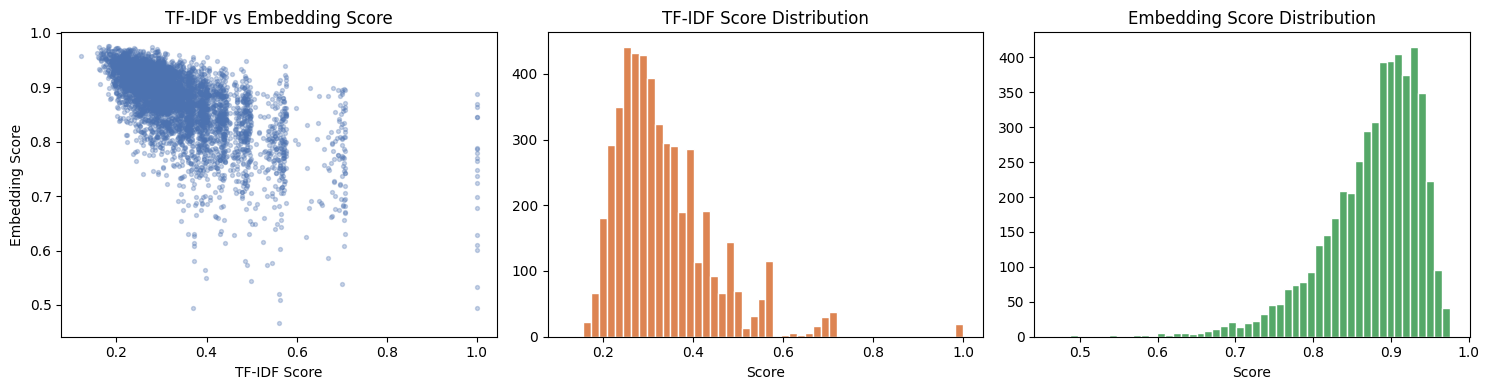


Correlation matrix:
                  tfidf_score  embedding_score  importance_score
tfidf_score             1.000           -0.635            -0.233
embedding_score        -0.635            1.000             0.750
importance_score       -0.233            0.750             1.000


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Sample for speed
sample = sent_df.sample(min(5000, len(sent_df)), random_state=42)

axes[0].scatter(sample['tfidf_score'], sample['embedding_score'],
                alpha=0.3, s=8, color='#4C72B0')
axes[0].set_xlabel('TF-IDF Score');  axes[0].set_ylabel('Embedding Score')
axes[0].set_title('TF-IDF vs Embedding Score')

axes[1].hist(sample['tfidf_score'],     bins=50, color='#DD8452', edgecolor='white')
axes[1].set_title('TF-IDF Score Distribution');  axes[1].set_xlabel('Score')

axes[2].hist(sample['embedding_score'], bins=50, color='#55A868', edgecolor='white')
axes[2].set_title('Embedding Score Distribution');  axes[2].set_xlabel('Score')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'feature_score_analysis.png'), dpi=120)
plt.show()

corr = sample[['tfidf_score', 'embedding_score', 'importance_score']].corr()
print('\nCorrelation matrix:')
print(corr.round(3))

## 8 — Save Features

In [ ]:
import pickle, json

# 8a. Document-level features (with lists) → pickle
doc_features = df[['article', 'highlights', 'clean_text',
                    'sentences', 'tfidf_scores',
                    'embedding_scores', 'importance_scores']].copy()

doc_features.to_pickle(os.path.join(OUTPUT_DIR, 'doc_features.pkl'))
print('✅  Saved  →  features/doc_features.pkl')

# 8b. Sentence-level feature table → CSV
sent_df.to_csv(os.path.join(OUTPUT_DIR, 'sentence_features.csv'), index=False)
print('✅  Saved  →  features/sentence_features.csv')

# 8c. TF-IDF vectorizer → pickle
with open(os.path.join(OUTPUT_DIR, 'tfidf_vectorizer.pkl'), 'wb') as f:
    pickle.dump(tfidf_vectorizer, f)
print('✅  Saved  →  features/tfidf_vectorizer.pkl')

# 8d. Word2Vec model
w2v_model.save(os.path.join(OUTPUT_DIR, 'word2vec.model'))
print('✅  Saved  →  features/word2vec.model')

# 8e. Config metadata
config = {
    'alpha'            : ALPHA,
    'tfidf_max_features': 20_000,
    'tfidf_ngram_range': [1, 2],
    'w2v_vector_size'  : w2v_model.vector_size,
    'w2v_window'       : 5,
    'w2v_min_count'    : 3,
    'w2v_sg'           : 1,
    'docs_processed'   : len(df)
}
with open(os.path.join(OUTPUT_DIR, 'feature_config.json'), 'w') as f:
    json.dump(config, f, indent=2)
print('✅  Saved  →  features/feature_config.json')

✅  Saved  →  features/doc_features.pkl
✅  Saved  →  features/sentence_features.csv
✅  Saved  →  features/tfidf_vectorizer.pkl
✅  Saved  →  features/word2vec.model
✅  Saved  →  features/feature_config.json


## 9 — Summary

| Feature | Description | Saved as |
|---------|-------------|----------|
| **TF-IDF matrix** | Corpus-level term weights (20k vocab, 1–2 grams) | `tfidf_vectorizer.pkl` |
| **TF-IDF sentence score** | Mean TF-IDF weight per sentence | inside `doc_features.pkl` |
| **Word2Vec embeddings** | 100-dim skip-gram trained on corpus | `word2vec.model` |
| **Embedding similarity** | Cosine similarity to document centroid | inside `doc_features.pkl` |
| **Combined importance** | α·TF-IDF + (1-α)·EmbSim, both normalised | `doc_features.pkl` & `sentence_features.csv` |


# **BaseLine Model**

In [ ]:
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

In [ ]:
def summarize_baseline(sentences, importance_scores, top_n=3):
    if not sentences:
        return ""

    #sort by scores
    ranked = sorted(
        enumerate(importance_scores),
        key=lambda x:x[1],
        reverse=True

    )[:top_n]

    indices= sorted([i for i,_ in ranked])  #to order them like their order in dovument
    return " ".join([sentences[i] for i in indices])

In [ ]:
df["baseline_summary"]= df.apply(
    lambda row:summarize_baseline(
        row["sentences"],
        row["importance_scores"],
        top_n=3

    ),
    axis=1

)

In [ ]:
#to check the difference in size of baseline and improved one

df["compression_baseline"]=df.apply(
    lambda r:len(r["baseline_summary"].split()) /len(r["article"].split()),
    axis=1
)



print("Baseline avg compression:",df["compression_baseline"].mean())


Baseline avg compression: 0.12205710240020871


In [ ]:
#Check that really the summary represent the real article meaning
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

model=SentenceTransformer('all-MiniLM-L6-v2')

def semantic_score(row):

    #change to vectors
    orig=model.encode(row["article"])
    summary=model.encode(row["baseline_summary"])
    return cosine_similarity([orig],[summary])[0][0]

df["semantic_score"]=df.apply(semantic_score,axis=1)
print("Semantic avg:",df["semantic_score"].mean())

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Semantic avg: 0.68485403


In [ ]:
#test
def test_baseline_sample(df,index=0):
    row =df.iloc[index]
    print(f"Article(first 400 chars):\n{row['article'][:400]}...\n")

    print("Basline Summary:\n")
    print(row["baseline_summary"])

    print(f"Compression:{row['compression_baseline']:.4f}")
    print(f"Semantic Similarity:{row['semantic_score']:.4f}")


In [ ]:
import random
for i in random.sample(range(len(df)),3):
     test_baseline_sample(df,i)

Article(first 400 chars):
(CNN)Amber Vinson says she followed all the rules when caring for an Ebola patient. So how did the Texas nurse contract the deadly virus? "I have no idea," she told CNN. "I go through it almost daily in my mind: what happened, what went wrong. Because I was covered completely every time. I followed the CDC protocol. ... I never strayed. It is a mystery to me." Vinson, who was declared Ebola-free l...

Basline Summary:

"I wouldn't have cared if she had triple Ebola Because I knew in my gut that she was alone " Vinson said nursing remains her passion, but she doesn't know when she'll be suiting up in scrubs again
Compression:0.0308
Semantic Similarity:0.7671
Article(first 400 chars):
By . John Mcgarry . Another difficult foreign assignment. Another remarkable performance and result from Tommy Wright’s indefatigable  St Johnstone. The Scottish Cup holders didn’t quite match their victories in Trondheim and Grodno of a year ago but this was still an outcome to be

# **Advanced Model: Transformer Summarizer**

For low-memory execution, the default model is `sshleifer/distilbart-cnn-6-6` instead of `facebook/bart-large-cnn`.

## 1 — Install/Import Requirements



In [1]:
# Colab install command if needed:
# !pip install -q transformers sentencepiece accelerate

import os
import re
import math
import gc
import pandas as pd
import torch

try:
    from google.colab import files
    IN_COLAB = True
except ImportError:
    files = None
    IN_COLAB = False

try:
    from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
except ImportError as exc:
    raise ImportError(
        "Install Transformer dependencies first: pip install transformers torch sentencepiece accelerate"
    ) from exc


## 2 — Load Articles for Standalone Advanced Run




In [2]:
# upload a CSV when prompted.
CSV_PATH = None

if CSV_PATH is None and IN_COLAB:
    uploaded = files.upload()
    CSV_PATH = next(iter(uploaded))

if CSV_PATH is None:
    CSV_PATH = "train.csv"

advanced_input_df = pd.read_csv(CSV_PATH)

if "article" not in advanced_input_df.columns:
    raise ValueError("The uploaded CSV must contain an 'article' column.")

advanced_input_df = advanced_input_df.dropna(subset=["article"]).copy()
if "highlights" not in advanced_input_df.columns:
    advanced_input_df["highlights"] = ""

print(f"Loaded {len(advanced_input_df):,} rows for the standalone advanced model")
print(advanced_input_df[["article", "highlights"]].head(1))


Saving test.csv to test.csv
Loaded 11,490 rows for the standalone advanced model
                                             article  \
0  Ever noticed how plane seats appear to be gett...   

                                          highlights  
0  Experts question if  packed out planes are put...  


## 3 — Load the Pretrained Transformer

DistilBART has an encoder-decoder architecture: the encoder reads the article, and the decoder generates the summary token by token. GPU is used automatically when available.

In [3]:
MODEL_NAME = "sshleifer/distilbart-cnn-6-6"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print(f"Loading {MODEL_NAME} on {DEVICE}...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
transformer_model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME).to(DEVICE)
transformer_model.eval()

# Keep memory pressure lower before inference.
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()


Loading sshleifer/distilbart-cnn-6-6 on cuda...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/460M [00:00<?, ?B/s]

Please make sure the generation config includes `forced_bos_token_id=0`. 


Loading weights:   0%|          | 0/262 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


model.safetensors:   0%|          | 0.00/460M [00:00<?, ?B/s]

## 4 — Handle Long Articles

Transformer models have a maximum input length. BART usually accepts up to 1024 tokens, so long articles are split into sentence-based chunks. Each chunk is summarized, then the chunk summaries are optionally summarized again into one final output.

In [4]:
def sentence_split_for_transformer(text):
    """Split text into sentences while reusing the preprocessing splitter when available."""
    if not isinstance(text, str) or not text.strip():
        return []
    if "fast_sentence_split" in globals():
        return fast_sentence_split(text)
    return [s.strip() for s in re.split(r"(?<=[.!?])\s+", text) if s.strip()]


def chunk_text_by_tokens(text, tokenizer, max_input_tokens=900):
    """Create chunks that fit the model while trying to keep sentence boundaries."""
    sentences = sentence_split_for_transformer(text)
    chunks = []
    current = []
    current_tokens = 0

    for sentence in sentences:
        sentence_tokens = len(tokenizer.encode(sentence, add_special_tokens=False))

        if sentence_tokens > max_input_tokens:
            if current:
                chunks.append(" ".join(current))
                current, current_tokens = [], 0
            token_ids = tokenizer.encode(sentence, add_special_tokens=False)
            for start in range(0, len(token_ids), max_input_tokens):
                chunks.append(tokenizer.decode(token_ids[start:start + max_input_tokens], skip_special_tokens=True))
            continue

        if current and current_tokens + sentence_tokens > max_input_tokens:
            chunks.append(" ".join(current))
            current = [sentence]
            current_tokens = sentence_tokens
        else:
            current.append(sentence)
            current_tokens += sentence_tokens

    if current:
        chunks.append(" ".join(current))

    return chunks or [text[:4000]]

## 5 — Generate Abstractive Summaries

`max_length` controls the longest summary, `min_length` prevents extremely short summaries, and `num_beams` improves generation quality by searching multiple candidate summaries.

In [5]:
def summarize_with_bart(
    text,
    max_input_tokens=512,
    max_length=80,
    min_length=20,
    num_beams=1,
    length_penalty=1.5,
):
    """Summarize one article with BART, including long-text chunk handling."""
    if not isinstance(text, str) or not text.strip():
        return ""

    chunks = chunk_text_by_tokens(text, tokenizer, max_input_tokens=max_input_tokens)
    chunk_summaries = []

    for chunk in chunks:
        inputs = tokenizer(
            chunk,
            return_tensors="pt",
            max_length=max_input_tokens,
            truncation=True,
        ).to(DEVICE)

        with torch.no_grad():
            summary_ids = transformer_model.generate(
                **inputs,
                max_length=max_length,
                min_length=min_length,
                num_beams=num_beams,
                length_penalty=length_penalty,
                early_stopping=True,
                no_repeat_ngram_size=3,
            )

        chunk_summaries.append(tokenizer.decode(summary_ids[0], skip_special_tokens=True))

    combined_summary = " ".join(chunk_summaries)

    if len(chunks) == 1:
        return combined_summary

    combined_tokens = len(tokenizer.encode(combined_summary, add_special_tokens=False))
    if combined_tokens <= max_input_tokens:
        inputs = tokenizer(combined_summary, return_tensors="pt", truncation=True, max_length=max_input_tokens).to(DEVICE)
        with torch.no_grad():
            final_ids = transformer_model.generate(
                **inputs,
                max_length=max_length,
                min_length=min_length,
                num_beams=num_beams,
                length_penalty=length_penalty,
                early_stopping=True,
                no_repeat_ngram_size=3,
            )
        return tokenizer.decode(final_ids[0], skip_special_tokens=True)

    return combined_summary

## 6 — Run the Advanced Model on a Sample

Transformer inference is slower than TF-IDF. Start with a small sample, inspect quality, then increase `ADVANCED_SAMPLE_SIZE` when the setup is stable.

In [10]:
ADVANCED_SAMPLE_SIZE = 10
advanced_df = advanced_input_df.head(ADVANCED_SAMPLE_SIZE).copy()

advanced_df["advanced_summary"] = advanced_df["article"].apply(summarize_with_bart)
advanced_df["advanced_compression"] = advanced_df.apply(
    lambda r: len(r["advanced_summary"].split()) / max(len(r["article"].split()), 1),
    axis=1,
)

display_columns = ["article", "highlights", "advanced_summary", "advanced_compression"]
if "baseline_summary" in advanced_df.columns:
    display_columns.insert(2, "baseline_summary")

advanced_df[display_columns].head()


,article,highlights,advanced_summary,advanced_compression
0,Ever noticed how plane seats appear to be gett...,Experts question if packed out planes are put...,"The FAA uses planes with a 31 inch pitch, a s...",0.105405
1,A drunk teenage boy had to be rescued by secur...,Drunk teenage boy climbed into lion enclosure ...,"Rahul Kumar, 17, climbed into the lions' encl...",0.192926
2,Dougie Freedman is on the verge of agreeing a ...,Nottingham Forest are close to extending Dougi...,Dougie Freedman is set to sign a new two-year...,0.345455
3,Liverpool target Neto is also wanted by PSG an...,Fiorentina goalkeeper Neto has been linked wit...,Liverpool and PSG are also interested in Fiore...,0.165584
4,Bruce Jenner will break his silence in a two-h...,"Tell-all interview with the reality TV star, 6...","The former Olympian and reality TV star, 65, ...",0.068091


## 7 — Compare Baseline vs Transformer

Use this view to explain the difference in your report: the baseline copies important sentences, while the Transformer can paraphrase and combine ideas into a shorter generated summary.

In [11]:
def show_advanced_example(dataframe, index=0):
    row = dataframe.iloc[index]
    print("ARTICLE:")
    print(row["article"], "...\n")

    print("REFERENCE HIGHLIGHTS:")
    print(row["highlights"], "\n")

    if "baseline_summary" in row:
        print("TF-IDF BASELINE SUMMARY:")
        print(row["baseline_summary"], "\n")

    print("TRANSFORMER ADVANCED SUMMARY:")
    print(row["advanced_summary"])

show_advanced_example(advanced_df, 0)

ARTICLE:
Ever noticed how plane seats appear to be getting smaller and smaller? With increasing numbers of people taking to the skies, some experts are questioning if having such packed out planes is putting passengers at risk. They say that the shrinking space on aeroplanes is not only uncomfortable - it's putting our health and safety in danger. More than squabbling over the arm rest, shrinking space on planes putting our health and safety in danger? This week, a U.S consumer advisory group set up by the Department of Transportation said at a public hearing that while the government is happy to set standards for animals flying on planes, it doesn't stipulate a minimum amount of space for humans. 'In a world where animals have more rights to space and food than humans,' said Charlie Leocha, consumer representative on the committee. 'It is time that the DOT and FAA take a stand for humane treatment of passengers.' But could crowding on planes lead to more serious issues than fighting f

## 8 — Save Advanced Outputs

The saved CSV can be used by the Evaluation Engineer to compute ROUGE and build comparison tables.

In [12]:
os.makedirs("clean_data", exist_ok=True)
advanced_output_path = "clean_data/advanced_summaries_sample.csv"

save_columns = ["article", "highlights", "advanced_summary", "advanced_compression"]
if "baseline_summary" in advanced_df.columns:
    save_columns.insert(2, "baseline_summary")

advanced_df[save_columns].to_csv(
    advanced_output_path,
    index=False,
)
print(f"Saved advanced summaries to {advanced_output_path}")


Saved advanced summaries to clean_data/advanced_summaries_sample.csv


## 9 — Report Notes for the Advanced Method

the advanced model as an abstractive Transformer summarizer based on BART. articles are split into token-limited chunks, each chunk is summarized, and multi-chunk outputs are summarized again. Important parameters to report are `max_input_tokens`, `max_length`, `min_length`, `num_beams`, and `length_penalty`.